In [43]:
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.v2 as v2

CLASSIFICATION_ROOT =  Path.cwd().parent / "data/processed/classification-expanded-boxes"

TRAIN_DIR = CLASSIFICATION_ROOT / "train"
DEV_DIR = CLASSIFICATION_ROOT / "dev"
NUM_SAMPLES_TO_PLOT = 21

ALLOWED_CLASSES = ['4', '5']

transforms = v2.Compose([
  v2.Resize((64, 64)),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.3994, 0.5100, 0.3541], std=[0.1831, 0.2149, 0.2105])
])

CLASS_NAMES = ["bud", "flower", "green", "pink", "purple", "blue"]
# g = torch.Generator().manual_seed(0)
# train_dataset = ImageFolder(TRAIN_DIR, transform=transforms)
# dev_dataset = ImageFolder(DEV_DIR, transform=transforms)

# train_dataloader = DataLoader(train_dataset, batch_size=NUM_SAMPLES_TO_PLOT, shuffle=True, num_workers=12, generator=g)
# dev_dataloader = DataLoader(dev_dataset, batch_size=NUM_SAMPLES_TO_PLOT, shuffle=True, num_workers=12, generator=g)

In [44]:
class FilteredImageFolder(ImageFolder):
  def __init__(self, root, allowed_classes, transform=None):
    super().__init__(root, transform=transform)

    # map class names → indices
    allowed_idx = {self.class_to_idx[c] for c in allowed_classes}

    # filter samples
    self.samples = [
      (path, label)
      for (path, label) in self.samples
      if label in allowed_idx
    ]

    # recompute targets (important for samplers, etc.)
    self.targets = [label for _, label in self.samples]

In [45]:
g = torch.Generator().manual_seed(0)
train_dataset = FilteredImageFolder(TRAIN_DIR, allowed_classes=ALLOWED_CLASSES, transform=transforms)
dev_dataset = FilteredImageFolder(DEV_DIR, allowed_classes=ALLOWED_CLASSES, transform=transforms)
train_dataloader = DataLoader(train_dataset, batch_size=NUM_SAMPLES_TO_PLOT, shuffle=True, num_workers=12, generator=g)
dev_dataloader = DataLoader(dev_dataset, batch_size=NUM_SAMPLES_TO_PLOT, shuffle=True, num_workers=12, generator=g)

In [46]:
def plot_prediction_dynamics(images:torch.Tensor, labels:torch.Tensor, preds:torch.Tensor):
  '''
  use one small constant batch (21) of test images to display predictions on during training. 
  For sanity check..
  '''
  fig, axes = plt.subplots(3, 7, figsize=(10, 4))

  for i, ax in enumerate(axes.flat):
    img = images[i]
    # img = (img - img.min()) / (img.max() - img.min()) # if it is normalized, this avoids range warning
    # CHW -> HWC
    img = img.permute(1,2,0)

    ax.imshow(img)

    label = labels[i].item()
    # pred = preds[i].item()
    # ax.set_title(f"{CLASS_NAMES[pred]}({CLASS_NAMES[label]})")
    ax.set_title(f"{CLASS_NAMES[label]}")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7315514..1.9736996].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7101338..-0.47124946].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.752969..0.7528942].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1232917..2.530558].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2817811..3.0684085].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6887162..1.2240821].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.410286

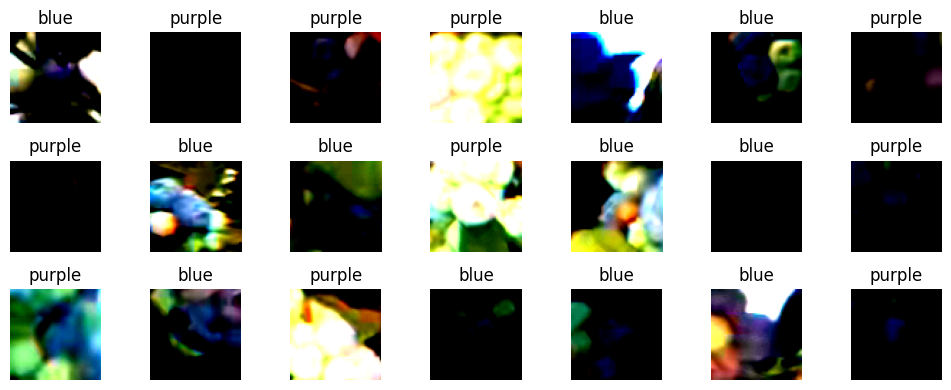

In [47]:
data, targets = next(iter(dev_dataloader))
plot_prediction_dynamics(data, targets, None)